# Further steps: figures

The data figures read the NIfTI volumes in `data/segthor_train_full` (corrected labels, 40 patients), the result figures read the saved predictions in `results/arch` and rebuild their ground truth from `data_old/segthor_part1_cleaned_old`.

In [2]:
%matplotlib inline
import pickle
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
from skimage.transform import resize

SRC = Path("data/segthor_train_full/train")
RUNS_DIR, RUNS_GT = Path("results/arch"), Path("data_old/segthor_part1_cleaned_old/train")
CACHE = Path("results/Data_analysis_fp.pkl")   # delete to recompute
ORGANS = ["esophagus", "heart", "trachea", "aorta"]                # labels 1-4, SegTHOR convention
RUN_ORGANS = ["aorta", "heart", "trachea", "esophagus"]            # labels 1-4 in cleaned_old
BINS = np.arange(-1200, 3105, 5); CENTERS = BINS[:-1] + 2.5        # 5 HU bins, outliers clamped
COLOR = {"esophagus": "#2a78d6", "heart": "#eb6834", "trachea": "#1baf7a", "aorta": "#4a3aa7"}
BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#c9c9c4"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e4e4e0", "axes.axisbelow": True, "axes.titleweight": "bold"})

## Per-patient statistics from the CT volumes (~5 min first run, then cached)

In [3]:
def hu_hist(v):
    return np.bincount(((np.clip(v, -1200, 3099) + 1200) // 5).ravel(), minlength=len(CENTERS))


def patient_stats(pid):
    img = nib.load(SRC / pid / f"{pid}.nii.gz")
    ct, gt = np.asarray(img.dataobj), np.asarray(nib.load(SRC / pid / "GT.nii.gz").dataobj)
    dx, dy, dz = map(float, img.header.get_zooms()[:3])
    s = {"id": pid.replace("Patient_", "P"), "dz": dz, "n": ct.shape[2], "fov": ct.shape[0] * dx,
         "length": ct.shape[2] * dz, "hu_max": int(ct.max()), "hist": hu_hist(ct),
         "fg_slices": (gt > 0).any((0, 1)), "organs": {}, "xy": {}}
    for k, o in enumerate(ORGANS, 1):
        m = gt == k
        s["organs"][o] = {"vol": m.sum() * dx * dy * dz / 1000, "med": float(np.median(ct[m])),
                          "hist": hu_hist(ct[m])}
        s["xy"][o] = m.any(2)
    zs = np.flatnonzero((gt == 2).any((0, 1)))                    # body width at mid-heart slice
    rows = np.flatnonzero((ct[:, :, (zs[0] + zs[-1]) // 2] > -500).any(1))
    s["body"] = (rows[-1] - rows[0] + 1) * dx
    return s


if CACHE.exists():
    P = pickle.load(open(CACHE, "rb"))
else:
    P = [patient_stats(p.name) for p in sorted(SRC.iterdir())]
    pickle.dump(P, open(CACHE, "wb"))
XY = {o: sum(s["xy"][o] for s in P) for o in ORGANS}             # patients with organ at pixel
pooled = lambda o=None: sum(s["organs"][o]["hist"] if o else s["hist"] for s in P)
print(len(P), "patients")

40 patients


## In-plane field of view and scanned area vs patient

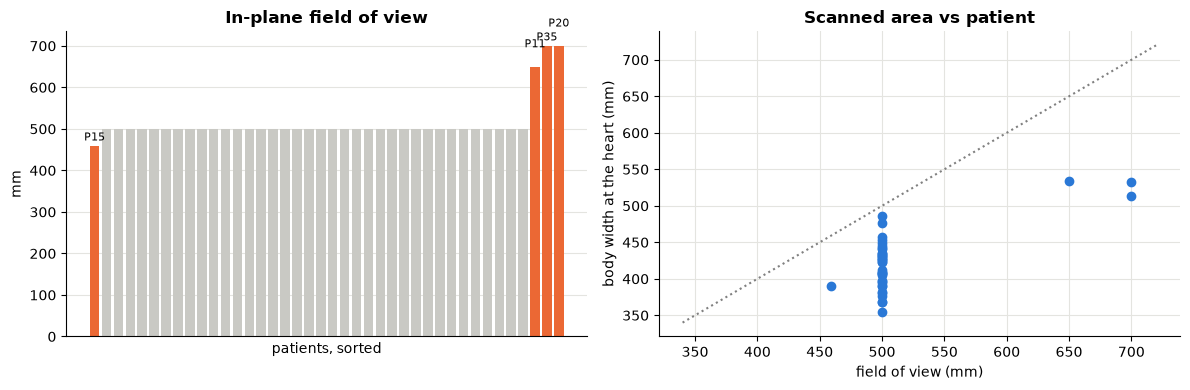

In [4]:
fov, body = np.array([s["fov"] for s in P]), np.array([s["body"] for s in P])
order = np.argsort(fov); odd = np.abs(fov - 500) > 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(range(len(P)), fov[order], color=np.where(odd[order], ORANGE, GREY))
for k, r in enumerate(np.flatnonzero(odd[order])):   # stagger: P20 and P35 are neighbours
    ax1.annotate(P[order[r]]["id"], (r, fov[order[r]]), ha="center", va="bottom", fontsize=8,
                 textcoords="offset points", xytext=(0, 2 + 10 * (k % 2)))
ax1.set(title="In-plane field of view", ylabel="mm", xlabel="patients, sorted", xticks=[])
ax2.scatter(fov, body, color=BLUE)
ax2.plot([340, 720], [340, 720], ":", color="grey")
ax2.set(title="Scanned area vs patient", xlabel="field of view (mm)",
        ylabel="body width at the heart (mm)")
plt.tight_layout(); plt.show()

## Scan length (slice thickness)

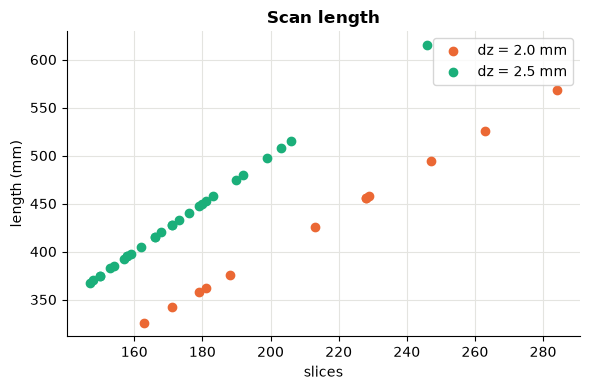

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
for v, c in [(2.0, ORANGE), (2.5, GREEN)]:
    sub = [s for s in P if s["dz"] == v]
    ax.scatter([s["n"] for s in sub], [s["length"] for s in sub], color=c, label=f"dz = {v} mm")
ax.set(title="Scan length", xlabel="slices", ylabel="length (mm)"); ax.legend()
plt.tight_layout(); plt.show()

## HU distributions (all voxels, per organ)

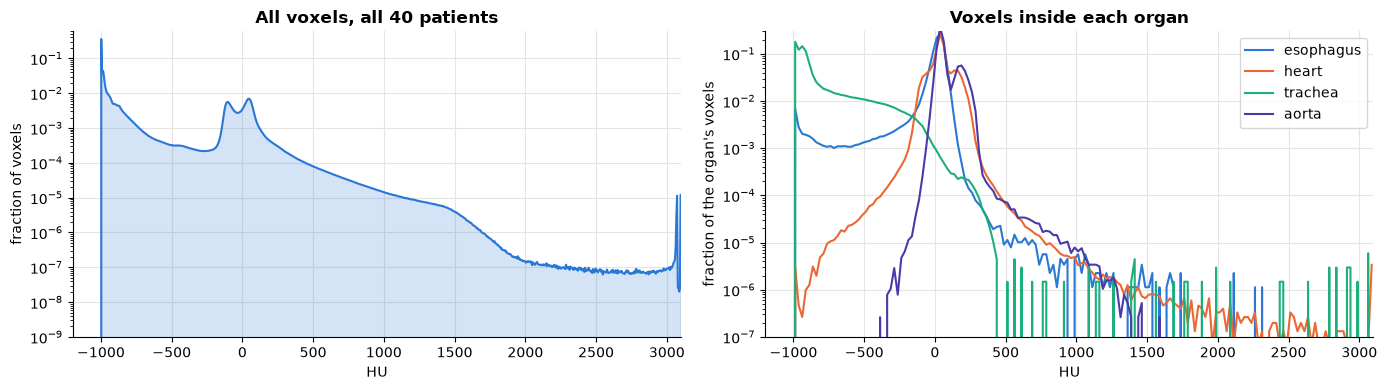

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
whole = pooled()
ax1.fill_between(CENTERS, whole / whole.sum(), alpha=0.2, color=BLUE)
ax1.plot(CENTERS, whole / whole.sum(), color=BLUE)
ax1.set(yscale="log", ylim=(1e-9, 0.6), title="All voxels, all 40 patients", xlabel="HU",
        ylabel="fraction of voxels")
for o in ORGANS:
    x, y = CENTERS.reshape(-1, 5).mean(1), pooled(o).reshape(-1, 5).sum(1)   # merge 5 bins
    ax2.plot(x, y / y.sum(), color=COLOR[o], label=o)
ax2.set(yscale="log", ylim=(1e-7, 0.3), title="Voxels inside each organ", xlabel="HU",
        ylabel="fraction of the organ's voxels"); ax2.legend()
for ax in (ax1, ax2):
    ax.set_xlim(BINS[0], BINS[-1])
plt.tight_layout(); plt.show()

## HU clips: share of each organ outside a clipping window

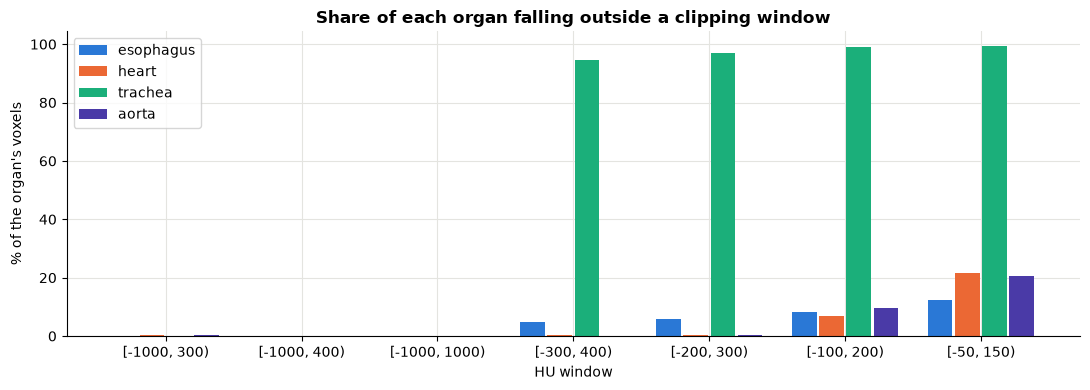

In [7]:
WINDOWS = [(-1000, 300), (-1000, 400), (-1000, 1000), (-300, 400), (-200, 300), (-100, 200), (-50, 150)]
fig, ax = plt.subplots(figsize=(11, 4))
for j, o in enumerate(ORGANS):
    c = pooled(o)
    out = [100 * (1 - c[(CENTERS >= lo) & (CENTERS < hi)].sum() / c.sum()) for lo, hi in WINDOWS]
    ax.bar(np.arange(len(WINDOWS)) + (j - 1.5) * 0.2, out, 0.18, color=COLOR[o], label=o)
ax.set_xticks(range(len(WINDOWS)), [f"[{lo}, {hi})" for lo, hi in WINDOWS])
ax.set(title="Share of each organ falling outside a clipping window", xlabel="HU window",
       ylabel="% of the organ's voxels"); ax.legend()
plt.tight_layout(); plt.show()

## Maximum HU per patient

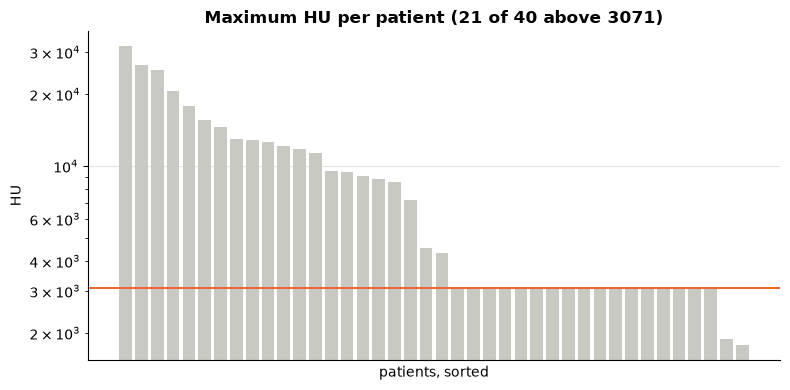

In [8]:
hu_max = np.sort([s["hu_max"] for s in P])[::-1]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(hu_max)), hu_max, color=GREY)
ax.axhline(3071, color=ORANGE)
ax.set(yscale="log", xticks=[], xlabel="patients, sorted", ylabel="HU",
       title=f"Maximum HU per patient ({(hu_max > 3071).sum()} of {len(hu_max)} above 3071)")
plt.tight_layout(); plt.show()

## Contrast enhancement: median organ HU per patient + shift table

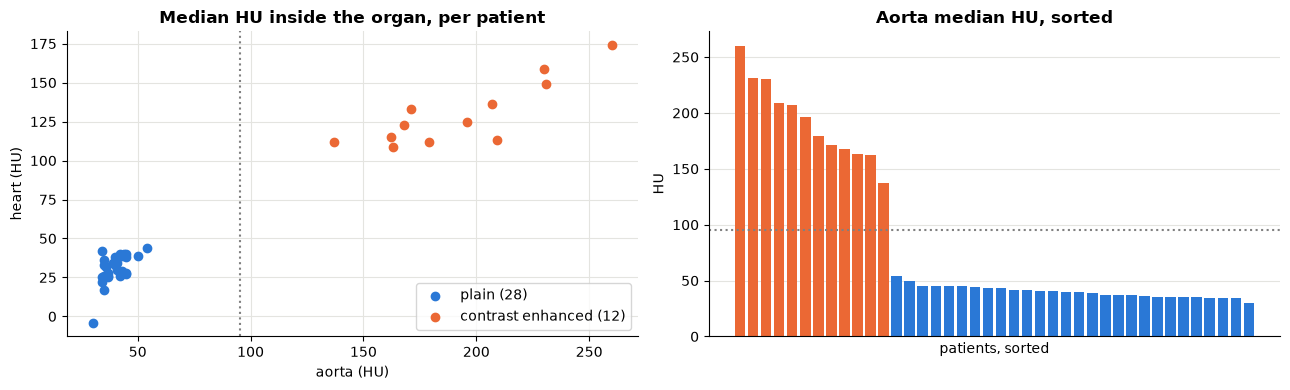

organ         plain  enhanced   shift   (median of per-patient medians)
esophagus        21        42     +20
heart            32       124     +92
trachea        -924      -897     +27
aorta            40       188    +148


In [9]:
med = {o: np.array([s["organs"][o]["med"] for s in P]) for o in ORGANS}
srt = np.sort(med["aorta"])
cut = (srt[:-1] + srt[1:])[np.argmax(np.diff(srt))] / 2     # widest gap in aorta HU
enh = med["aorta"] > cut

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for m, c, lab in [(~enh, BLUE, "plain"), (enh, ORANGE, "contrast enhanced")]:
    ax1.scatter(med["aorta"][m], med["heart"][m], color=c, label=f"{lab} ({m.sum()})")
ax1.axvline(cut, ls=":", color="grey")
ax1.set(title="Median HU inside the organ, per patient", xlabel="aorta (HU)", ylabel="heart (HU)")
ax1.legend()
order = np.argsort(-med["aorta"])
ax2.bar(range(len(P)), med["aorta"][order], color=np.where(enh[order], ORANGE, BLUE))
ax2.axhline(cut, ls=":", color="grey")
ax2.set(title="Aorta median HU, sorted", ylabel="HU", xlabel="patients, sorted", xticks=[])
plt.tight_layout(); plt.show()

print(f"{'organ':<11}{'plain':>8}{'enhanced':>10}{'shift':>8}   (median of per-patient medians)")
for o in ORGANS:
    a, b = np.median(med[o][~enh]), np.median(med[o][enh])
    print(f"{o:<11}{a:>8.0f}{b:>10.0f}{b - a:>+8.0f}")

## Vertical crop: empty slices below / above the organ block

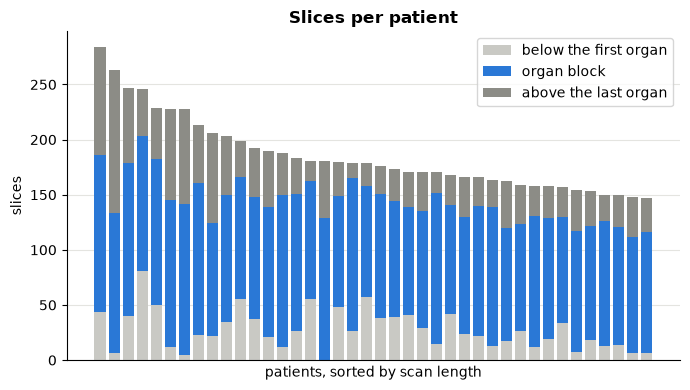

In [10]:
rows = []
for s in P:
    z = np.flatnonzero(s["fg_slices"])
    rows.append((z[0], z[-1] - z[0] + 1, s["n"] - 1 - z[-1]))
lead, block, trail = np.array(rows).T
order = np.argsort(-(lead + block + trail))

fig, ax = plt.subplots(figsize=(7, 4))
bottom = np.zeros(len(P))
for v, c, lab in [(lead, GREY, "below the first organ"), (block, BLUE, "organ block"),
                  (trail, "#8c8c86", "above the last organ")]:
    ax.bar(range(len(P)), v[order], bottom=bottom, color=c, label=lab)
    bottom += v[order]
ax.set(title="Slices per patient", ylabel="slices", xlabel="patients, sorted by scan length",
       xticks=[]); ax.legend()
plt.tight_layout(); plt.show()

## Horizontal crop: organ occupancy per pixel

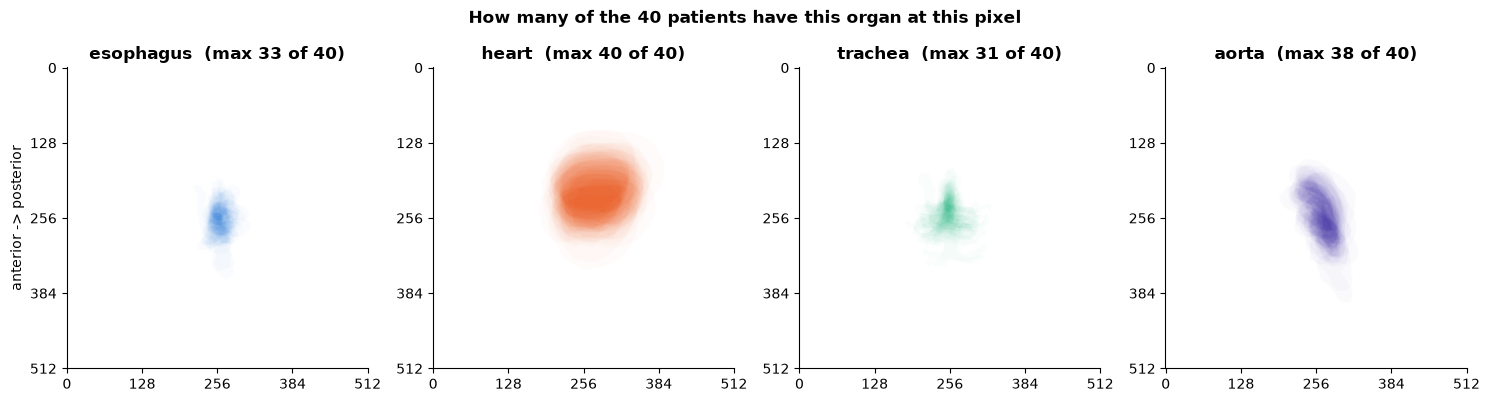

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, o in zip(axes, ORGANS):
    cmap = LinearSegmentedColormap.from_list(o, ["white", COLOR[o]])
    ax.imshow(XY[o].T, cmap=cmap, vmin=0, vmax=len(P))
    ax.set(title=f"{o}  (max {XY[o].max()} of {len(P)})", xticks=[0, 128, 256, 384, 512],
           yticks=[0, 128, 256, 384, 512]); ax.grid(False)
axes[0].set_ylabel("anterior -> posterior")
fig.suptitle("How many of the 40 patients have this organ at this pixel", fontweight="bold")
plt.tight_layout(); plt.show()

## Class distribution: organ volume and share of the foreground

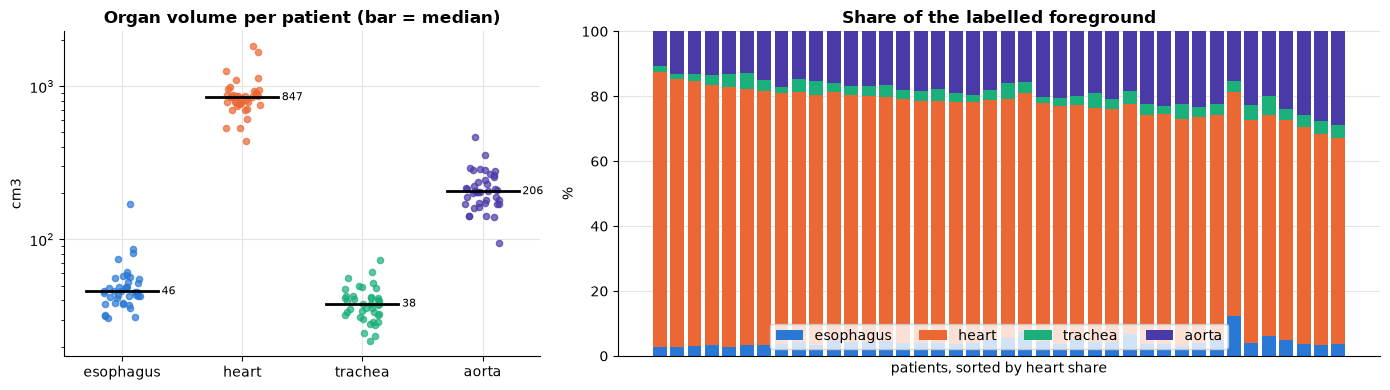

In [12]:
vol = {o: np.array([s["organs"][o]["vol"] for s in P]) for o in ORGANS}
fg = sum(vol.values())
rng = np.random.default_rng(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [1, 1.6]})
for i, o in enumerate(ORGANS):
    ax1.scatter(i + (rng.random(len(P)) - 0.5) * 0.3, vol[o], s=20, alpha=0.7, color=COLOR[o])
    ax1.plot([i - 0.3, i + 0.3], [np.median(vol[o])] * 2, color="k", lw=2)
    ax1.annotate(f"{np.median(vol[o]):.0f}", (i + 0.33, np.median(vol[o])), va="center", fontsize=8)
ax1.set(yscale="log", title="Organ volume per patient (bar = median)", ylabel="cm3")
ax1.set_xticks(range(len(ORGANS)), ORGANS)
order = np.argsort(-vol["heart"] / fg); bottom = np.zeros(len(P))
for o in ORGANS:
    share = 100 * vol[o][order] / fg[order]
    ax2.bar(range(len(P)), share, bottom=bottom, color=COLOR[o], label=o); bottom += share
ax2.set(ylim=(0, 100), title="Share of the labelled foreground", ylabel="%",
        xlabel="patients, sorted by heart share", xticks=[])
ax2.legend(ncol=4, loc="lower center")
plt.tight_layout(); plt.show()

## Result analysis: evaluate the baseline runs from their saved predictions

The `results/arch` runs were trained on `segthor_part1_cleaned_old` (label 1 = aorta, 4 = esophagus),
so the ground truth is rebuilt from those volumes, sliced and resized like `slice_segthor.py`. (This is only for the three baseline runs of enet, unet and vit)

In [13]:
stems = [p.stem for p in sorted((RUNS_DIR / "unet/best_epoch/val").glob("*.png"))]
pids = np.array([s.rsplit("_", 1)[0] for s in stems])
vols = {p: np.asarray(nib.load(RUNS_GT / p / "GT.nii.gz").dataobj) for p in np.unique(pids)}
gt = np.stack([resize(vols[s.rsplit("_", 1)[0]][:, :, int(s.rsplit("_", 1)[1])], (256, 256),
                      order=0, preserve_range=True, anti_aliasing=False, mode="constant")
               for s in stems]).astype(np.uint8)


def evaluate(run):
    pred = np.stack([np.asarray(Image.open(RUNS_DIR / run / "best_epoch/val" / f"{s}.png"))
                     for s in stems]) // 63
    dice_val = np.load(RUNS_DIR / run / "dice_val.npy")
    best = dice_val[:, :, 1:].mean((1, 2)).argmax()
    r = {"run": run, "logged": dice_val[best, :, 1:].mean(), "vol": {}, "fail": {},
         "confusion": np.bincount(gt.ravel().astype(int) * 5 + pred.ravel(), minlength=25).reshape(5, 5)}
    for k, o in enumerate(RUN_ORGANS, 1):
        g, q = gt == k, pred == k
        r["vol"][o] = np.mean([2 * (g[pids == p] & q[pids == p]).sum() / (g[pids == p].sum() + q[pids == p].sum())
                               for p in np.unique(pids)])        # volumetric DSC, mean over patients
        gs, qs = g.any((1, 2)), q.any((1, 2))
        r["fail"][o] = {"found": (gs & qs).sum(), "missed": (gs & ~qs).sum(), "fp": (~gs & qs).sum()}
    return r


RUNS = [evaluate(r) for r in ["enet", "unet", "vit"]]
RUN_COLOR = dict(zip(["enet", "unet", "vit"], [BLUE, ORANGE, GREEN]))

## Logged vs volumetric DSC

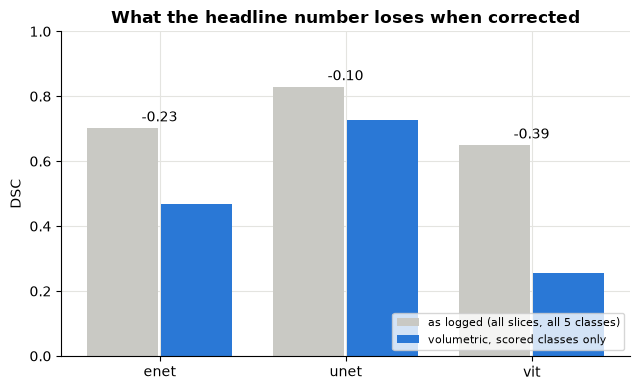

In [14]:
logged = [r["logged"] for r in RUNS]
volumetric = [np.mean(list(r["vol"].values())) for r in RUNS]
x = np.arange(len(RUNS))
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(x - 0.2, logged, 0.38, color=GREY, label="as logged (all slices, all 5 classes)")
ax.bar(x + 0.2, volumetric, 0.38, color=BLUE, label="volumetric, scored classes only")
for i, (a, b) in enumerate(zip(logged, volumetric)):
    ax.annotate(f"-{a - b:.2f}", (i, max(a, b) + 0.02), ha="center")
ax.set_xticks(x, [r["run"] for r in RUNS])
ax.set(ylim=(0, 1), ylabel="DSC", title="What the headline number loses when corrected")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

## Volumetric DSC per class

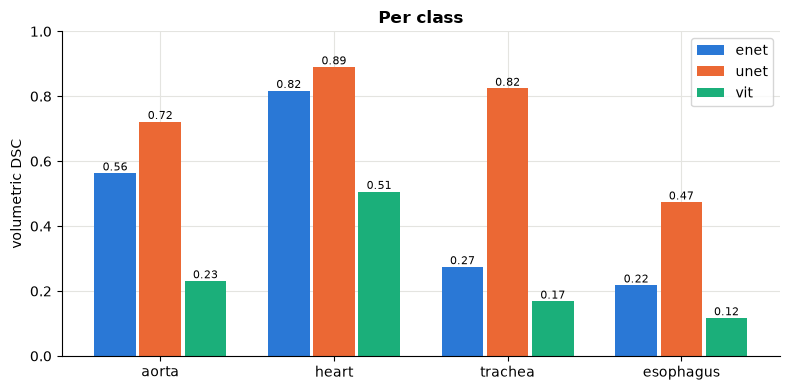

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
for j, r in enumerate(RUNS):
    v = [r["vol"][o] for o in RUN_ORGANS]
    xs = np.arange(len(RUN_ORGANS)) + (j - 1) * 0.26
    ax.bar(xs, v, 0.24, color=RUN_COLOR[r["run"]], label=r["run"])
    for xi, vi in zip(xs, v):
        ax.annotate(f"{vi:.2f}", (xi, vi), ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(len(RUN_ORGANS)), RUN_ORGANS)
ax.set(ylim=(0, 1), ylabel="volumetric DSC", title="Per class"); ax.legend()
plt.tight_layout(); plt.show()

## Binary slice-level outcome per class

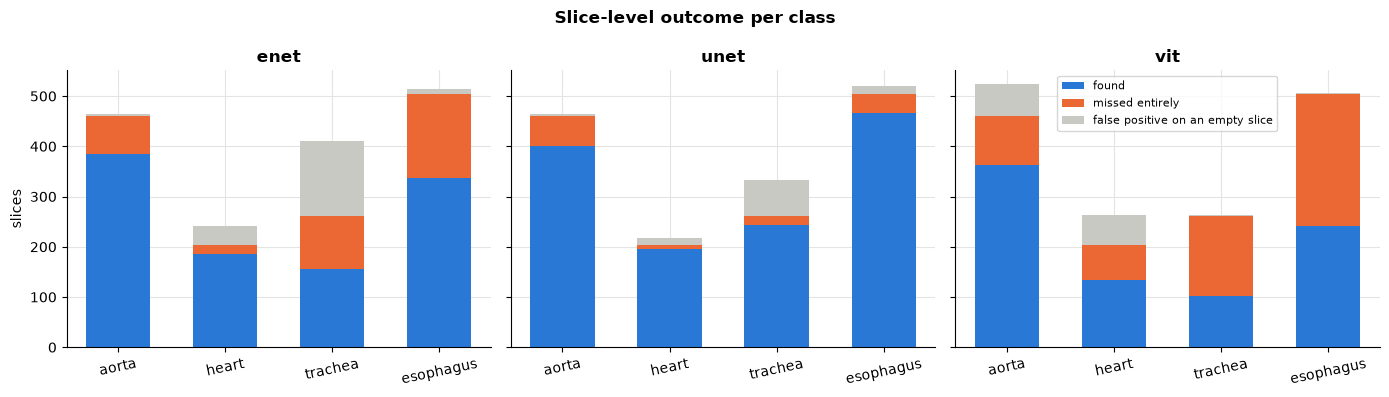

In [16]:
fig, axes = plt.subplots(1, len(RUNS), figsize=(14, 4), sharey=True)
for ax, r in zip(axes, RUNS):
    bottom = np.zeros(len(RUN_ORGANS))
    for key, c, lab in [("found", BLUE, "found"), ("missed", ORANGE, "missed entirely"),
                        ("fp", GREY, "false positive on an empty slice")]:
        v = np.array([r["fail"][o][key] for o in RUN_ORGANS])
        ax.bar(range(len(RUN_ORGANS)), v, 0.6, bottom=bottom, color=c, label=lab); bottom += v
    ax.set_xticks(range(len(RUN_ORGANS)), RUN_ORGANS, rotation=12); ax.set_title(r["run"])
axes[0].set_ylabel("slices"); axes[-1].legend(fontsize=8)
fig.suptitle("Slice-level outcome per class", fontweight="bold")
plt.tight_layout(); plt.show()

## Confusion matrix (best run)

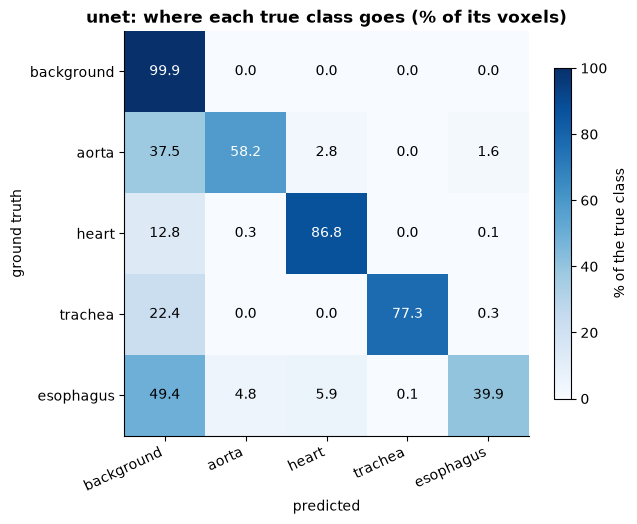

In [17]:
best = max(RUNS, key=lambda r: np.mean(list(r["vol"].values())))
cm = 100 * best["confusion"] / best["confusion"].sum(1, keepdims=True)
labels = ["background"] + RUN_ORGANS
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=100)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{cm[i, j]:.1f}", ha="center", va="center",
                color="white" if cm[i, j] > 55 else "black")
ax.set_xticks(range(5), labels, rotation=25, ha="right")
ax.set_yticks(range(5), labels); ax.grid(False)
ax.set(xlabel="predicted", ylabel="ground truth",
       title=f"{best['run']}: where each true class goes (% of its voxels)")
fig.colorbar(im, ax=ax, shrink=0.75, label="% of the true class")
plt.tight_layout(); plt.show()